In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


✅ All imports done


In [3]:
df = pd.read_csv("archive/train_u6lujuX_CVtuZ9i.csv")

def create_features(df):
    df = df.copy()
    df['Dependents'] = df['Dependents'].replace('3+', '3')
    df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)
    df['TotalIncome']     = df['ApplicantIncome'] + df['CoapplicantIncome']
    df['EMI']             = df['LoanAmount'] / df['Loan_Amount_Term'].replace(0, np.nan)
    df['LoanIncomeRatio'] = df['LoanAmount'] / (df['TotalIncome'] + 1)
    df['IncomePerPerson'] = df['TotalIncome'] / (df['Dependents'] + 1)
    df['Loan_Term_Years'] = df['Loan_Amount_Term'] / 12
    df['Has_Coapplicant'] = (df['CoapplicantIncome'] > 0).astype(int)
    df['EMI_to_Income']   = df['EMI'] / (df['TotalIncome'] + 1)
    return df

df = create_features(df)

NUMERIC_FEATURES = [
    'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
    'Loan_Amount_Term', 'TotalIncome', 'EMI',
    'LoanIncomeRatio', 'IncomePerPerson', 'Loan_Term_Years',
    'Has_Coapplicant', 'EMI_to_Income'
]

CATEGORICAL_FEATURES = [
    'Gender', 'Married', 'Dependents',
    'Education', 'Self_Employed',
    'Property_Area', 'Credit_History'
]

le = LabelEncoder()
df['Loan_Status_Binary'] = le.fit_transform(df['Loan_Status'])

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df['Loan_Status_Binary']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train={X_train.shape}, X_test={X_test.shape}")

X_train=(491, 18), X_test=(123, 18)


In [4]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric',     numeric_pipeline,     NUMERIC_FEATURES),
    ('categorical', categorical_pipeline, CATEGORICAL_FEATURES)
])

lr_pipeline  = joblib.load('lr_pipeline.pkl')
rf_pipeline  = joblib.load('rf_pipeline.pkl')
xgb_pipeline = joblib.load('xgb_pipeline.pkl')


In [5]:
models = [
    ("Logistic Regression", lr_pipeline),
    ("Random Forest",       rf_pipeline),
    ("XGBoost",             xgb_pipeline)
]

print("5-Fold Cross Validation Results")
print("=" * 45)

cv_results = []

for name, pipeline in models:
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')
    cv_results.append({
        'Model'   : name,
        'CV Mean' : round(scores.mean(), 4),
        'CV Std'  : round(scores.std(), 4),
        'Min'     : round(scores.min(), 4),
        'Max'     : round(scores.max(), 4)
    })
    print(f"{name}")
    print(f"  AUC per fold : {np.round(scores, 3)}")
    print(f"  Mean ± Std   : {scores.mean():.3f} ± {scores.std():.3f}")
    print()

cv_df = pd.DataFrame(cv_results)
display(cv_df)

5-Fold Cross Validation Results
Logistic Regression
  AUC per fold : [0.831 0.746 0.824 0.842 0.737]
  Mean ± Std   : 0.796 ± 0.045

Random Forest
  AUC per fold : [0.723 0.707 0.807 0.846 0.774]
  Mean ± Std   : 0.771 ± 0.052

XGBoost
  AUC per fold : [0.742 0.734 0.784 0.831 0.732]
  Mean ± Std   : 0.765 ± 0.038



,Model,CV Mean,CV Std,Min,Max
0,Logistic Regression,0.7959,0.0452,0.7368,0.8422
1,Random Forest,0.7715,0.0516,0.7067,0.8458
2,XGBoost,0.7647,0.0384,0.7318,0.8312


In [6]:
rf_param_grid = {
    'model__n_estimators'      : [100, 200, 300],
    'model__max_depth'         : [3, 5, 7, None],
    'model__min_samples_split' : [2, 5, 10],
    'model__min_samples_leaf'  : [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator  = rf_pipeline,
    param_grid = rf_param_grid,
    cv         = 5,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

rf_grid.fit(X_train, y_train)

print(f"\n Best Parameters : {rf_grid.best_params_}")
print(f"Best CV AUC     : {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

 Best Parameters : {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV AUC     : 0.7677


In [7]:
xgb_param_grid = {
    'model__n_estimators' : [100, 200, 300],
    'model__max_depth'    : [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample'    : [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator  = xgb_pipeline,
    param_grid = xgb_param_grid,
    cv         = 5,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

xgb_grid.fit(X_train, y_train)

print(f"\nBest Parameters : {xgb_grid.best_params_}")
print(f" Best CV AUC     : {xgb_grid.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters : {'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}
 Best CV AUC     : 0.7493


In [8]:
def get_metrics(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4)
    }

comparison = [
    get_metrics("RF — Before Tuning",  rf_pipeline,          X_test, y_test),
    get_metrics("RF — After Tuning",   rf_grid.best_estimator_,  X_test, y_test),
    get_metrics("XGB — Before Tuning", xgb_pipeline,         X_test, y_test),
    get_metrics("XGB — After Tuning",  xgb_grid.best_estimator_, X_test, y_test),
]

comparison_df = pd.DataFrame(comparison)
print("Before vs After Tuning:")
display(comparison_df)

Before vs After Tuning:


,Model,Accuracy,F1 Score,ROC-AUC
0,RF — Before Tuning,85.37,89.66,0.8743
1,RF — After Tuning,85.37,89.66,0.8666
2,XGB — Before Tuning,82.11,87.36,0.8263
3,XGB — After Tuning,86.18,90.81,0.8687


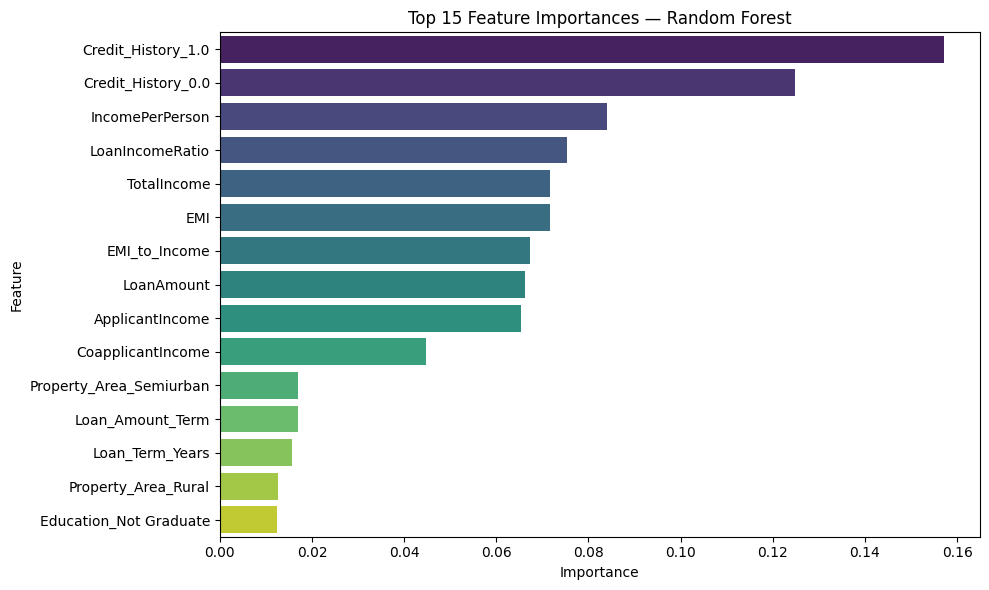

In [9]:
rf_best = rf_grid.best_estimator_

# Get feature names after OneHotEncoding
ohe_features = rf_best.named_steps['preprocessor']\
    .named_transformers_['categorical']\
    .named_steps['encoder']\
    .get_feature_names_out(CATEGORICAL_FEATURES).tolist()

all_features = NUMERIC_FEATURES + ohe_features

# Get importances
importances = rf_best.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

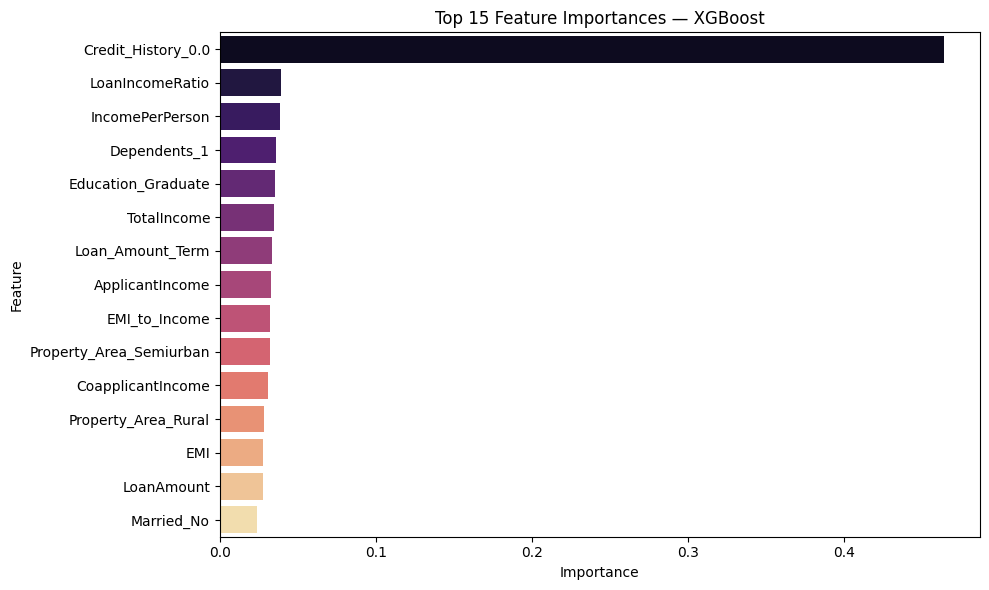

XGBoost Feature Importance plotted


In [13]:
xgb_best = xgb_grid.best_estimator_

# Get feature names after encoding
ohe_features = xgb_best.named_steps['preprocessor']\
    .named_transformers_['categorical']\
    .named_steps['encoder']\
    .get_feature_names_out(CATEGORICAL_FEATURES).tolist()

all_features = NUMERIC_FEATURES + ohe_features

# XGBoost built-in feature importance
importances = xgb_best.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

print("XGBoost Feature Importance plotted")

In [14]:
joblib.dump(rf_grid.best_estimator_,  'rf_tuned_pipeline.pkl')
joblib.dump(xgb_grid.best_estimator_, 'xgb_tuned_pipeline.pkl')

print(" Tuned models saved!")
print("\nPhase 4 Complete!")
print("Next → Phase 5: Business Recommendations + Final Presentation")

 Tuned models saved!

Phase 4 Complete!
Next → Phase 5: Business Recommendations + Final Presentation


In [17]:
import joblib
import pandas as pd
import numpy as np

# Load best model
model = joblib.load('rf_tuned_pipeline.pkl')

# Sample new applicant details
new_applicant = pd.DataFrame([{
    'Gender'            : 'Male',
    'Married'           : 'Yes',
    'Dependents'        : '0',
    'Education'         : 'Graduate',
    'Self_Employed'     : 'No',
    'ApplicantIncome'   : 5000,
    'CoapplicantIncome' : 2000,
    'LoanAmount'        : 120,
    'Loan_Amount_Term'  : 360,
    'Credit_History'    : 1,
    'Property_Area'     : 'Urban'
}])

# Apply feature engineering
def create_features(df):
    df = df.copy()
    df['Dependents'] = df['Dependents'].replace('3+', '3')
    df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)
    df['TotalIncome']     = df['ApplicantIncome'] + df['CoapplicantIncome']
    df['EMI']             = df['LoanAmount'] / df['Loan_Amount_Term'].replace(0, np.nan)
    df['LoanIncomeRatio'] = df['LoanAmount'] / (df['TotalIncome'] + 1)
    df['IncomePerPerson'] = df['TotalIncome'] / (df['Dependents'] + 1)
    df['Loan_Term_Years'] = df['Loan_Amount_Term'] / 12
    df['Has_Coapplicant'] = (df['CoapplicantIncome'] > 0).astype(int)
    df['EMI_to_Income']   = df['EMI'] / (df['TotalIncome'] + 1)
    return df

new_applicant = create_features(new_applicant)

# Predict
prediction   = model.predict(new_applicant)[0]
probability  = model.predict_proba(new_applicant)[0][1]

print("=" * 40)
print("       LOAN APPROVAL PREDICTION")
print("=" * 40)
print(f"Applicant Income   : ₹{5000}")
print(f"Coapplicant Income : ₹{2000}")
print(f"Loan Amount        : ₹{120}k")
print(f"Credit History     : Yes")
print("-" * 40)
print(f"Decision           : {'APPROVED' if prediction == 1 else 'REJECTED'}")
print(f"Confidence         : {probability * 100:.1f}%")
print("=" * 40)

       LOAN APPROVAL PREDICTION
Applicant Income   : ₹5000
Coapplicant Income : ₹2000
Loan Amount        : ₹120k
Credit History     : Yes
----------------------------------------
Decision           : APPROVED
Confidence         : 69.3%
